In [1]:
import json
import torch
import numpy as np
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.nn import functional as F
from IPython.display import clear_output
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 15, 'font.family': 'serif'})

## 1. Adversarial examples

In [5]:
%%bash
wget https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json
wget https://i.natgeofe.com/k/66d3a80c-f4c3-4410-845c-3543375eaa85/cheetah-watching_square.jpg -O cheetah.jpg

--2026-02-05 17:19:27--  https://i.natgeofe.com/k/66d3a80c-f4c3-4410-845c-3543375eaa85/cheetah-watching_square.jpg
Resolving i.natgeofe.com (i.natgeofe.com)... 23.35.105.73, 23.35.105.41, 2a02:26f0:7700::1723:6949, ...
com)|23.35.105.73|:443... connected.eofe.
HTTP request sent, awaiting response... 200 OK
Length: 1085277 (1.0M) [image/jpeg]
Saving to: ‘cheetah.jpg’

     0K .......... .....

Process was interrupted.


CalledProcessError: Command 'b'# wget https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json\nwget https://i.natgeofe.com/k/66d3a80c-f4c3-4410-845c-3543375eaa85/cheetah-watching_square.jpg -O cheetah.jpg\n'' died with <Signals.SIGINT: 2>.

In [2]:
from torchvision.models import mobilenet_v3_small
from torchvision import transforms as T
from PIL import Image

In [3]:
model = mobilenet_v3_small(weights="IMAGENET1K_V1")
model.eval()
sum(param.numel() for param in model.parameters())

2542856

In [4]:
class_idx = json.load(open('imagenet_class_index.json'))
idx2label = [class_idx[str(k)][1] for k in range(len(class_idx))]

In [5]:
normalize = T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
to_tensor = T.ToTensor()
to_image = T.ToPILImage()

@torch.no_grad()
def predict(image):
    probs = model(
        normalize(to_tensor(image)).unsqueeze(0)
    ).squeeze().softmax(dim=0)

    class_id = probs.argmax().item()
    print(f'class ID: {class_id}, class name: {idx2label[class_id]}, '
          f'confidence: {100 * probs[class_id].item():.2f}%')

class ID: 293, class name: cheetah, confidence: 87.03%


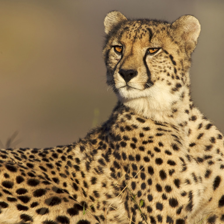

In [6]:
image = Image.open('cheetah-watching_square.jpg').resize((224, 224))
predict(image)
image

In [7]:
def fgsm(image, label, targeted=False, eps=1/255, iters=1):
    x = nn.Parameter(to_tensor(image), requires_grad=True)
    opt = torch.optim.SGD([x], lr=0.999 * eps / iters)  # multiply adversarial budget by constant < 1 to keep
    criterion = nn.CrossEntropyLoss()                   # actual difference between pixels within range
    target = torch.tensor([label])

    for _ in range(iters):
        opt.zero_grad()
        logits = model(normalize(x).unsqueeze(0))
        loss = criterion(logits, target)

        if not targeted:  # negative loss for untargeted attacks
            loss = -loss

        loss.backward()
#         print(torch.norm(x.grad))
        x.grad = torch.sign(x.grad)  # replace gradient with a sign of gradient
#         print(torch.norm(x.grad))
        opt.step()
        x.data = torch.clip(x.data, 0, 1)  # clip to range of images

    return to_image(x.data)

### Single step untargeted FGSM

In [9]:
idx2label[293]

'cheetah'

class ID: 288, class name: leopard, confidence: 53.43%
difference max norm: 1.0 pixels


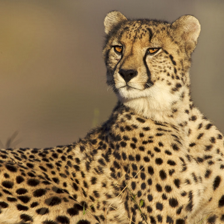

In [10]:
adv_image = fgsm(image, 293, targeted=False, eps=1/255, iters=1)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

class ID: 290, class name: jaguar, confidence: 61.02%
difference max norm: 2.0 pixels


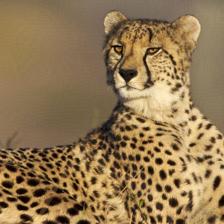

In [11]:
adv_image = fgsm(image, 293, targeted=False, eps=2/256, iters=1)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

class ID: 290, class name: jaguar, confidence: 79.40%
difference max norm: 4.0 pixels


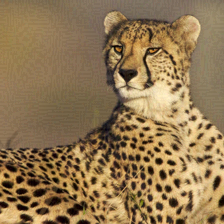

In [12]:
adv_image = fgsm(image, 293, targeted=False, eps=4/256, iters=1)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

class ID: 290, class name: jaguar, confidence: 83.81%
difference max norm: 8.0 pixels


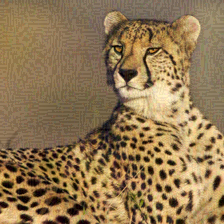

In [13]:
adv_image = fgsm(image, 293, targeted=False, eps=8/255, iters=1)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

class ID: 290, class name: jaguar, confidence: 86.71%
difference max norm: 16.0 pixels


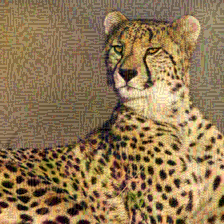

In [15]:
adv_image = fgsm(image, 293, targeted=False, eps=16/255, iters=1)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

class ID: 109, class name: brain_coral, confidence: 62.13%
difference max norm: 32.0 pixels


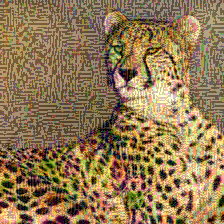

In [14]:
adv_image = fgsm(image, 293, targeted=False, eps=32/255, iters=1)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

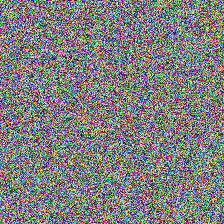

In [16]:
image2 = np.random.rand(*np.array(image).shape)
image2 = Image.fromarray((image2 * 255).astype(np.uint8))
image2

In [17]:
predict(image2)

class ID: 21, class name: kite, confidence: 16.53%


class ID: 293, class name: cheetah, confidence: 61.62%
difference max norm: 254.0 pixels


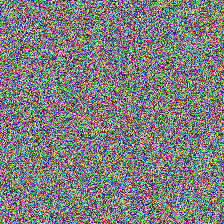

In [18]:
adv_image = fgsm(image2, 293, targeted=True, eps=5/255, iters=100)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

class ID: 489, class name: chainlink_fence, confidence: 16.97%
difference max norm: 255.0 pixels


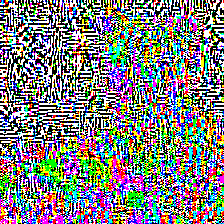

In [19]:
adv_image = fgsm(image, 293, targeted=False, eps=5, iters=1)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

### Iterative untargeted FGSM

class ID: 290, class name: jaguar, confidence: 87.91%
difference max norm: 1.0 pixels


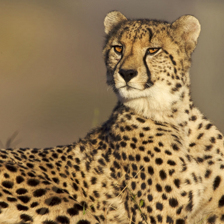

In [20]:
adv_image = fgsm(image, 293, targeted=False, eps=1/255, iters=16)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

class ID: 290, class name: jaguar, confidence: 79.40%
difference max norm: 4.0 pixels


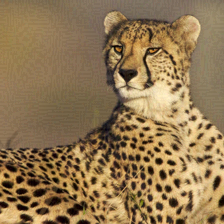

In [21]:
adv_image = fgsm(image, 293, targeted=False, eps=4/255, iters=1)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

class ID: 290, class name: jaguar, confidence: 100.00%
difference max norm: 16.0 pixels


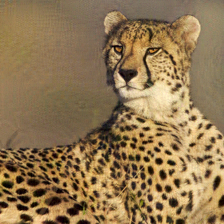

In [22]:
adv_image = fgsm(image, 293, targeted=False, eps=16/255, iters=16)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

### Iterative targeted FGSM

In [23]:
idx2label[620]

'laptop'

class ID: 293, class name: cheetah, confidence: 54.72%
difference max norm: 1.0 pixels


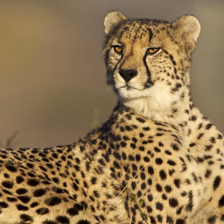

In [24]:
adv_image = fgsm(image, 620, targeted=True, eps=1/255, iters=16)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

class ID: 620, class name: laptop, confidence: 91.21%
difference max norm: 2.0 pixels


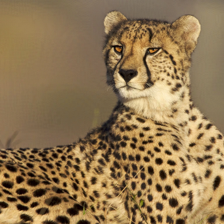

In [25]:
adv_image = fgsm(image, 620, targeted=True, eps=2/255, iters=16)
predict(adv_image)
max_norm = np.max(np.abs(np.array(image, dtype=float) - np.array(adv_image, dtype=float)))
print(f'difference max norm: {max_norm} pixels')
adv_image

## 2. Generative Adversarial Network

In [11]:
class SyntheticDataset(Dataset):
    def __init__(self, num_modes=8, scale=0.1, rings=1, num_samples=10000):
        # assert rings in [1, 2]
        self.num_modes = num_modes
        self.scale = scale
        self.num_samples = num_samples
        angles = torch.linspace(0, 2 * torch.pi, num_modes + 1)[:-1]
        self.centers = torch.stack([angles.cos(), angles.sin()], dim=1)

        for i in range(1, rings):
            out_angles = angles + (i % 2) * torch.pi / num_modes
            out_centers = torch.stack([(i + 1) * out_angles.cos(), (i + 1) * out_angles.sin()], dim=1)
            self.centers = torch.cat([
                self.centers, out_centers
            ], dim=0)

        if rings > 1:
            self.centers *= 2 / rings
        self.samples, self.assignments = self.sample(num_samples)

    def sample(self, num_samples):
        samples = self.scale * torch.randn(num_samples, 2)
        assignments = torch.randint(high=self.centers.shape[0], size=(num_samples, ))
        samples = samples + self.centers[assignments]
        return samples, assignments

    def __len__(self):
        return self.num_samples

    def __getitem__(self, item):
        return self.samples[item]


def draw_samples(ax, samples, centers, title='synthetic data'):
    ax.scatter(samples[:, 0], samples[:, 1],
                alpha=0.02, color='orange', label='sample')
    ax.scatter(centers[:, 0], centers[:, 1],
                color='blue', s=200, marker='*', label='modes')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    legend = ax.legend(title=title)
    for lh in legend.legend_handles: 
        lh.set_alpha(1)


def plot_losses(ax, losses_G, losses_D):
    ax.plot(range(1, len(losses_G) + 1), losses_G, label='Generator')
    ax.plot(range(1, len(losses_D) + 1), losses_D, label='Discriminator')
    ax.set_ylabel('loss')
    ax.set_xlabel('iter')
    ax.legend()

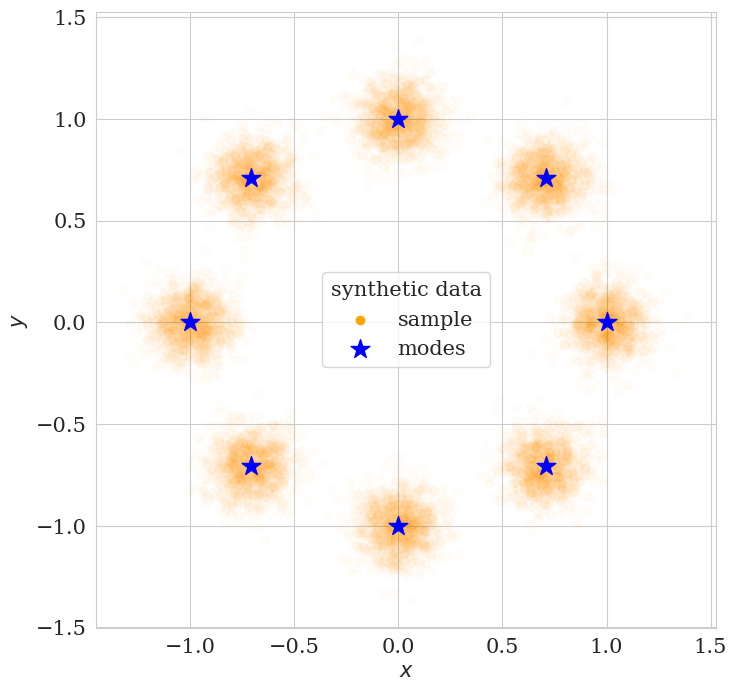

In [27]:
dataset = SyntheticDataset(num_modes=8, scale=0.1, num_samples=10000)

plt.figure(figsize=(8, 8))
draw_samples(plt.axes(), dataset.samples, dataset.centers)

In [10]:
def network(num_layers, input_dim, mlp_dim, out_dim):
    assert num_layers >= 2
    layers = [
        nn.Linear(input_dim, mlp_dim),
        nn.LeakyReLU(0.1)
    ]

    for i in range(num_layers - 2):
        layers += [
            nn.Linear(mlp_dim, mlp_dim),
            nn.LeakyReLU(0.1)
        ]
        if i % 2 == 0:
            layers.append(nn.BatchNorm1d(mlp_dim))

    layers += [
        nn.Linear(mlp_dim, out_dim)
    ]

    return nn.Sequential(*layers)

In [29]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [30]:
from scipy.ndimage import gaussian_filter1d


class GAN(object):
    def __init__(self, num_layers_gen=4, num_layers_dis=4, noise_dim=8, mlp_dim=16, out_dim=2):
        self.num_layers_gen = num_layers_gen
        self.num_layers_dis = num_layers_dis
        self.noise_dim = noise_dim
        self.mlp_dim = mlp_dim
        self.out_dim = out_dim

        self.net_G = network(num_layers=num_layers_gen, input_dim=noise_dim,
                             mlp_dim=mlp_dim, out_dim=out_dim).to(device)
        self.net_D = network(num_layers=num_layers_dis, input_dim=out_dim,
                             mlp_dim=mlp_dim, out_dim=1).to(device)

        self.opt_G = torch.optim.Adam(self.net_G.parameters(), lr=7e-4)
        self.opt_D = torch.optim.Adam(self.net_D.parameters(), lr=5e-4)
#         self.criterion = nn.BCEWithLogitsLoss()

        params_G = sum(param.numel() for param in self.net_G.parameters())
        params_D = sum(param.numel() for param in self.net_D.parameters())
        print(f'Generator params: {params_G}, Discriminator params: {params_D}')

        self.losses_G, self.losses_D = [], []

    def train(self, dataloader, num_epochs):
        self.net_G.train(), self.net_D.train()

        for epoch in tqdm(range(1, num_epochs + 1)):
            for x_real in dataloader:
                x_real = x_real.to(device)
                fake_labels = torch.zeros(x_real.shape[0]).to(device)
                real_labels = torch.ones(x_real.shape[0]).to(device)

                self.opt_G.zero_grad()
                self.opt_D.zero_grad()

                z = torch.randn(x_real.shape[0], self.noise_dim).to(device)
                x_fake = self.net_G(z)

                logits_fake = self.net_D(x_fake.detach()).squeeze()
                logits_real = self.net_D(x_real).squeeze()
#                 loss_D = self.criterion(logits_fake, fake_labels) + \
#                          self.criterion(logits_real, real_labels)
                loss_D = ((logits_fake - fake_labels) ** 2).mean() + ((logits_real - real_labels) ** 2).mean()
                loss_D.backward()
                self.opt_D.step()

                # here we can freeze net_D
                logits_fake = self.net_D(x_fake).squeeze()
#                 loss_G = self.criterion(logits_fake, real_labels)
                loss_G = ((logits_fake - real_labels) ** 2).mean()
                loss_G.backward()
                self.opt_G.step()

                self.losses_G.append(loss_G.item())
                self.losses_D.append(loss_D.item())

    @torch.inference_mode()
    def sample(self, num_samples):
        self.net_G.eval()
        z = torch.randn(num_samples, self.noise_dim).to(device)
        samples = self.net_G(z)
        return samples.cpu()

    def visualize(self):
        fig, axs = plt.subplots(1, 2, figsize=(16, 8))
        samples = self.sample(num_samples=10000)

        plot_losses(axs[0], gaussian_filter1d(self.losses_G, sigma=30),
                    gaussian_filter1d(self.losses_D, sigma=30))

        draw_samples(axs[1], samples, dataset.centers, title='Generator samples')
        axs[0].set_xticks(np.linspace(0, len(self.losses_G), 5))
        axs[1].set_xlim((-2.5, 2.5))
        axs[1].set_ylim((-2.5, 2.5))
        plt.show()

### GAN training process

In [49]:
gan = GAN()
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)

Generator params: 754, Discriminator params: 641


In [51]:
gan.train(dataloader, num_epochs=30)

  0%|          | 0/30 [00:00<?, ?it/s]

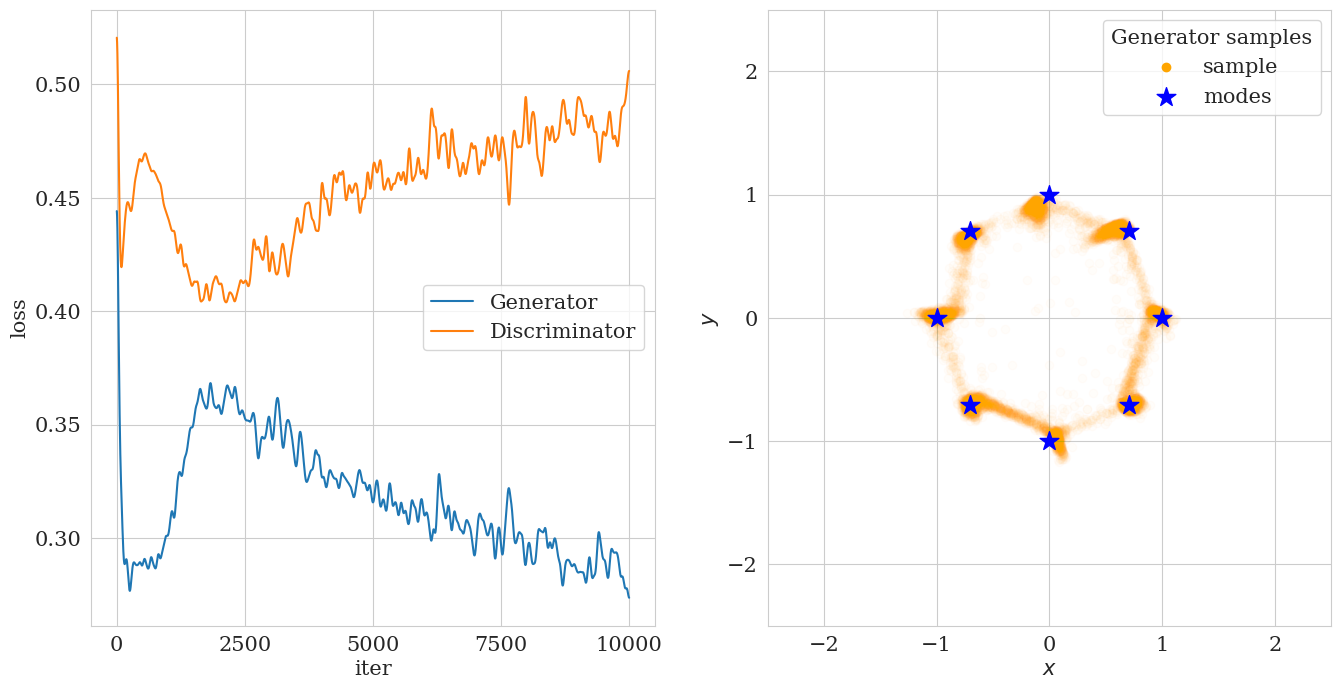

In [52]:
gan.visualize()

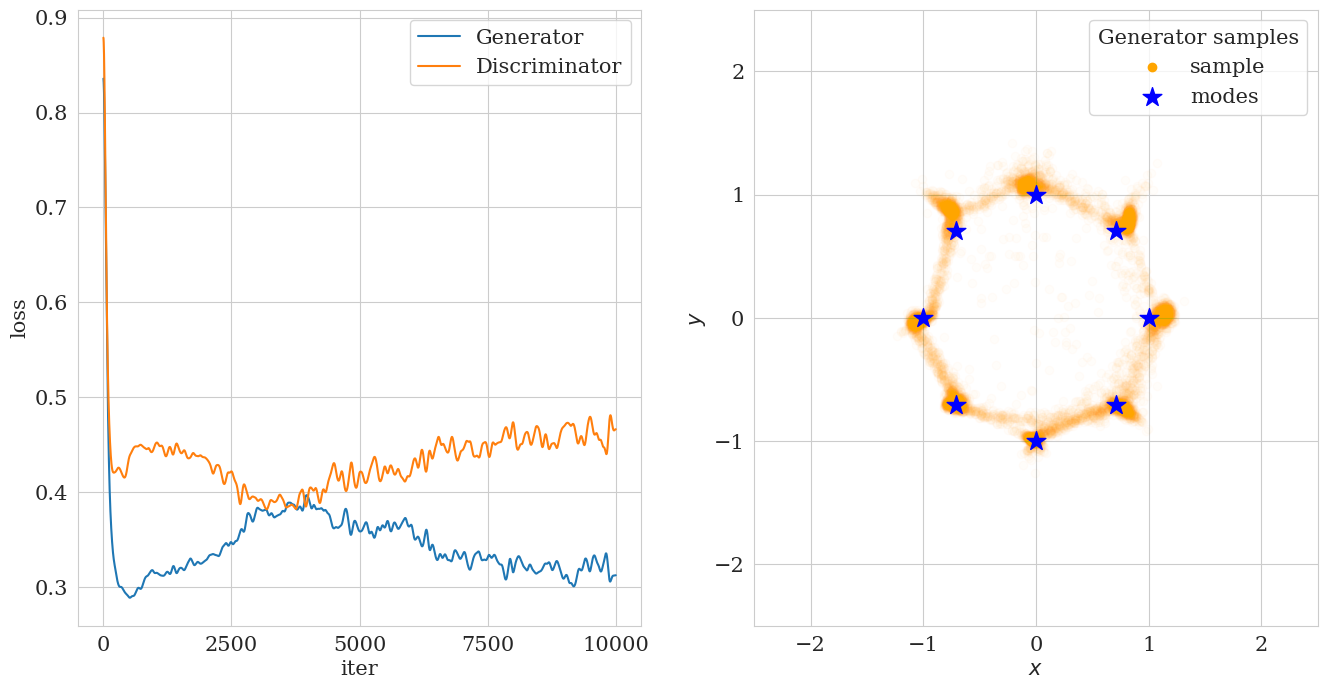

In [36]:
gan.visualize()

In [37]:
gan = GAN(num_layers_gen=23, num_layers_dis=6)
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)

Generator params: 6242, Discriminator params: 1217


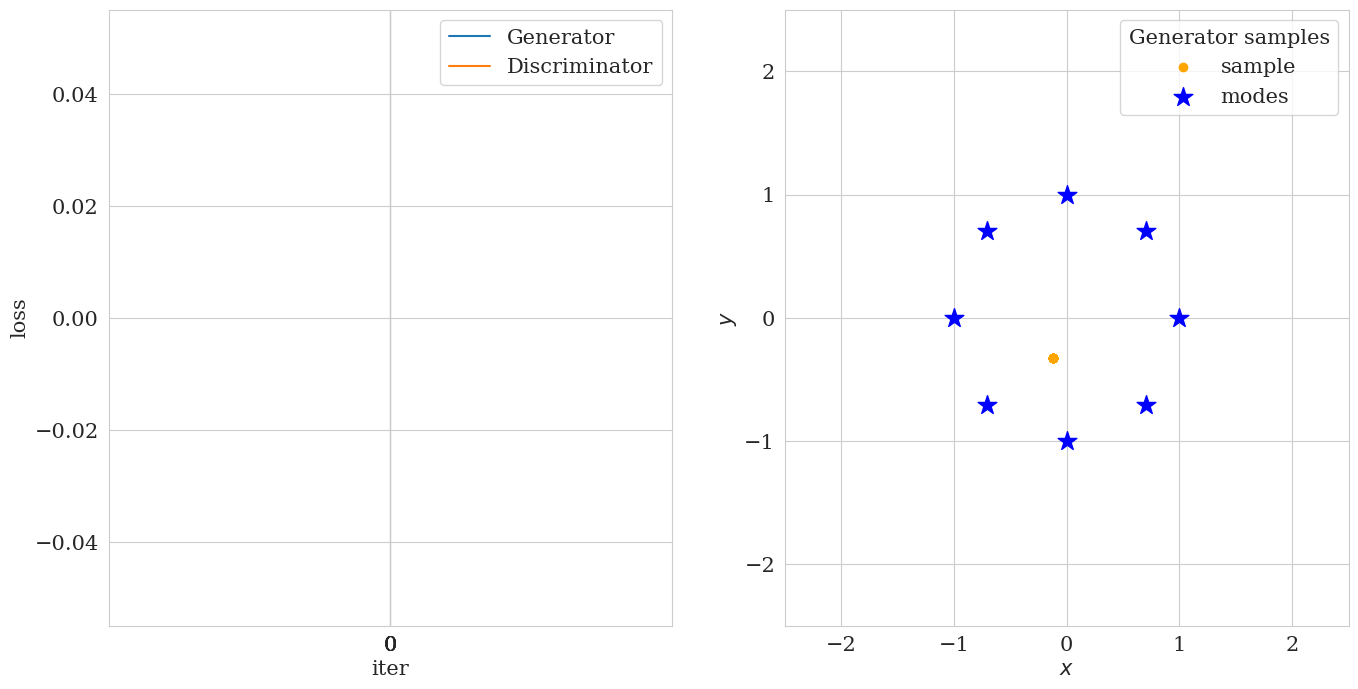

In [38]:
gan.visualize()

In [39]:
gan.train(dataloader, num_epochs=1)

  0%|          | 0/1 [00:00<?, ?it/s]

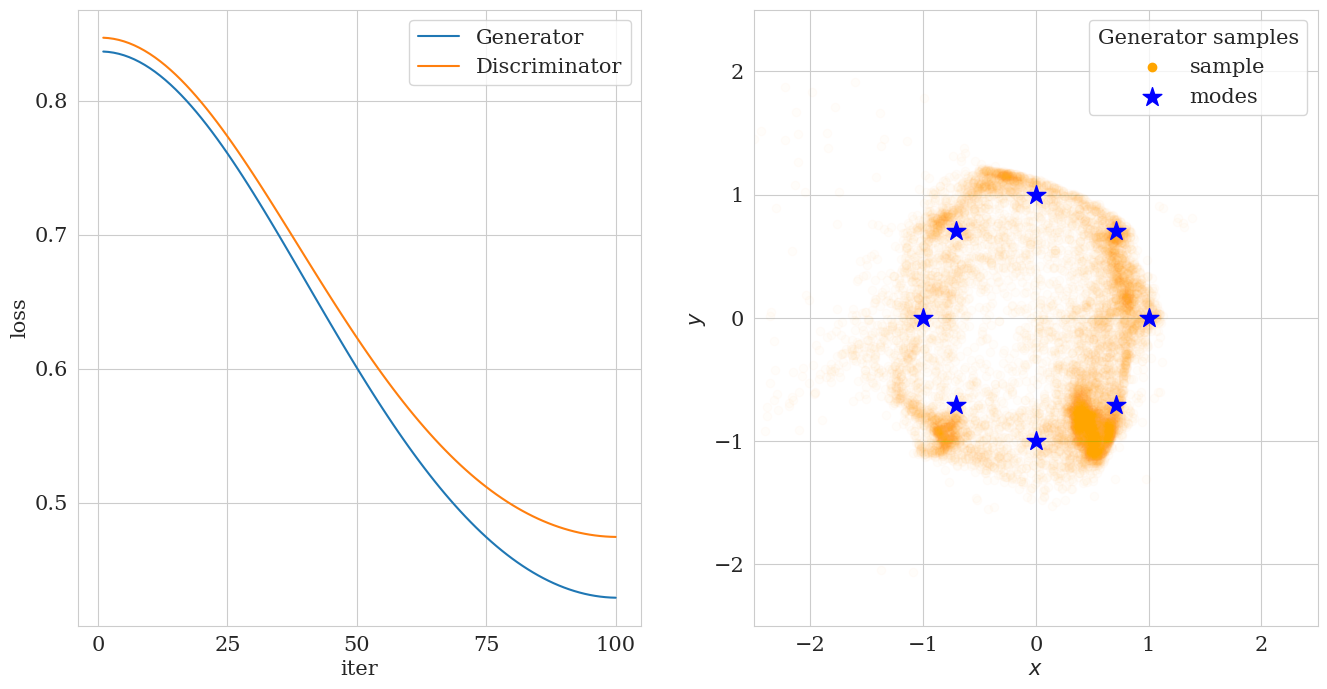

In [40]:
gan.visualize()

In [41]:
gan.train(dataloader, num_epochs=5)

  0%|          | 0/5 [00:00<?, ?it/s]

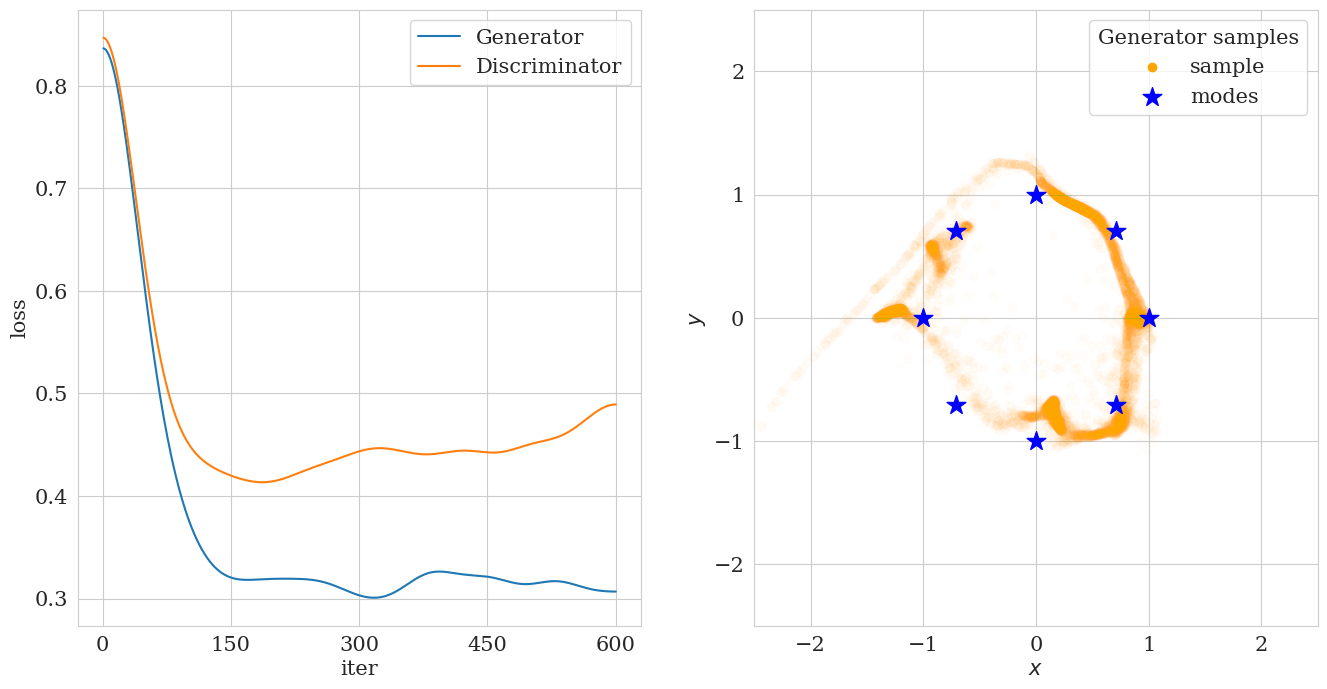

In [42]:
gan.visualize()

In [43]:
gan.train(dataloader, num_epochs=10)

  0%|          | 0/10 [00:00<?, ?it/s]

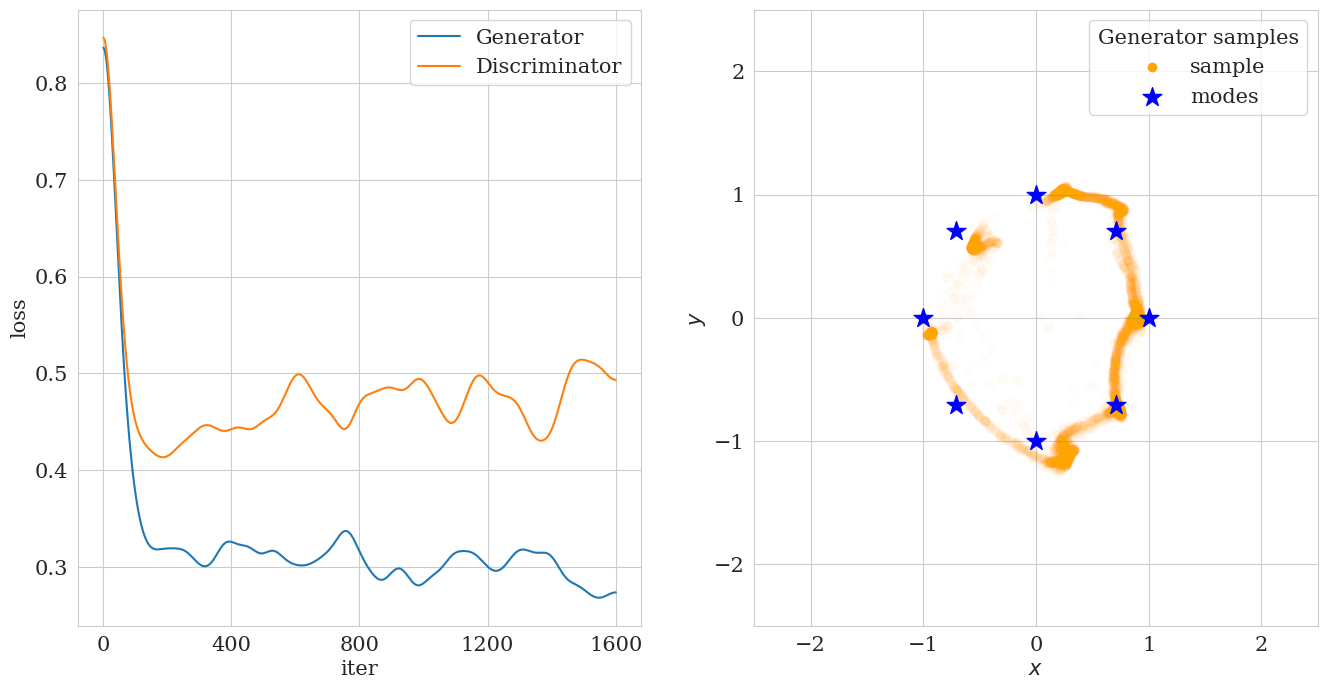

In [44]:
gan.visualize()

In [45]:
gan.train(dataloader, num_epochs=30)

  0%|          | 0/30 [00:00<?, ?it/s]

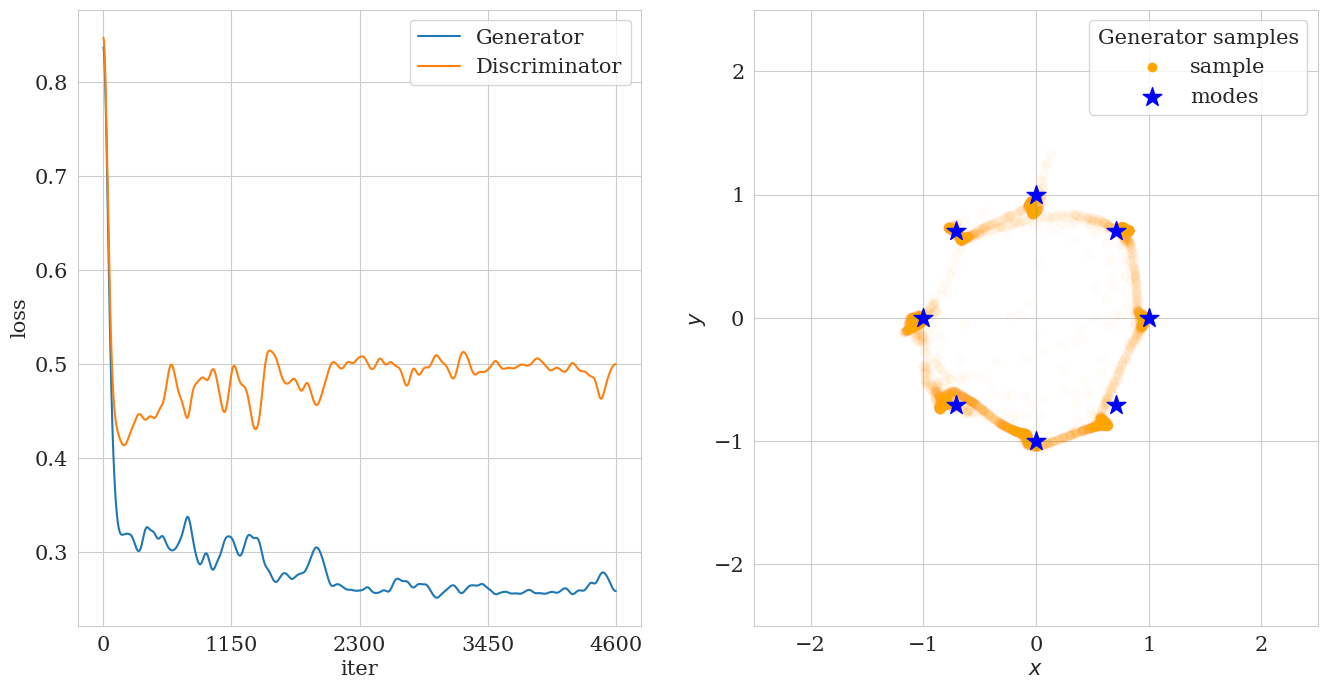

In [46]:
gan.visualize()

In [47]:
gan.train(dataloader, num_epochs=100)

  0%|          | 0/100 [00:00<?, ?it/s]

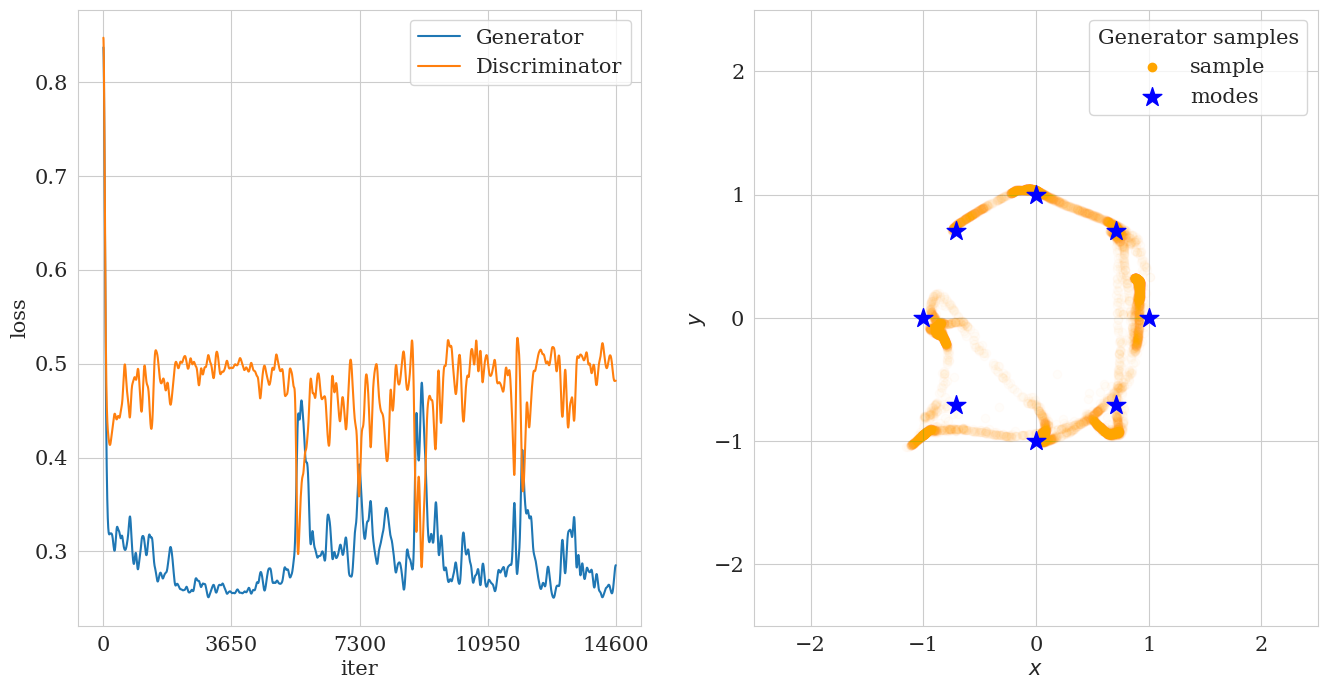

In [48]:
gan.visualize()

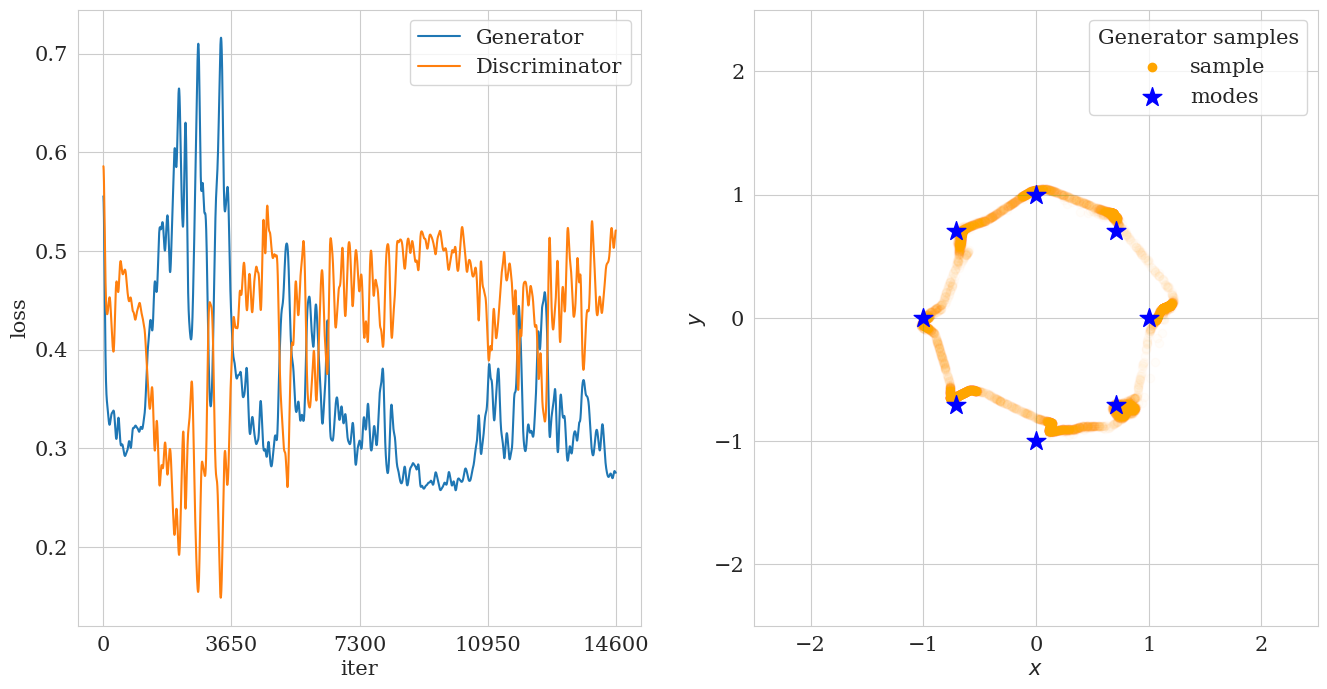

In [240]:
gan.visualize()

### Mode collapsing

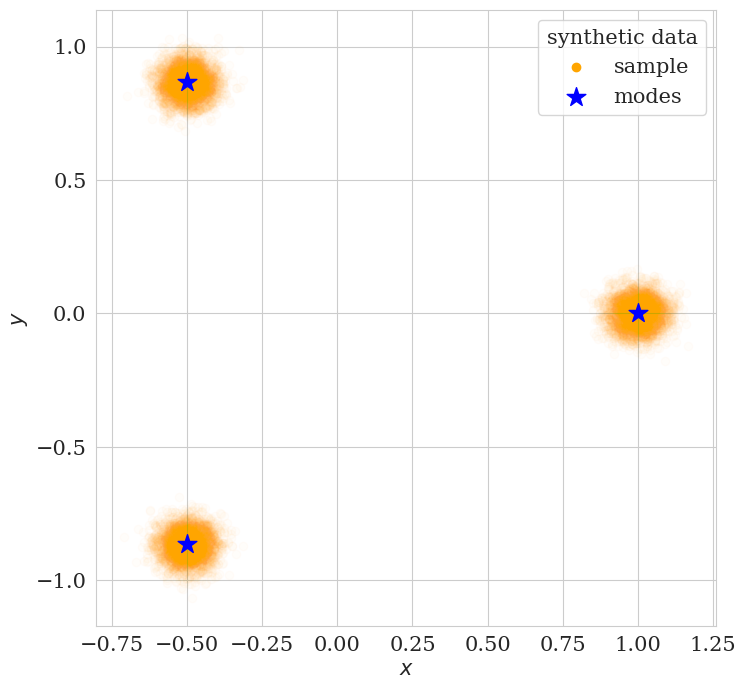

In [64]:
dataset = SyntheticDataset(num_modes=3, scale=0.05, num_samples=10000)

plt.figure(figsize=(8, 8))
draw_samples(plt.axes(), dataset.samples, dataset.centers)

In [65]:
gan = GAN()
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)
gan.train(dataloader, num_epochs=100)

Generator params: 754, Discriminator params: 641


  0%|          | 0/200 [00:00<?, ?it/s]

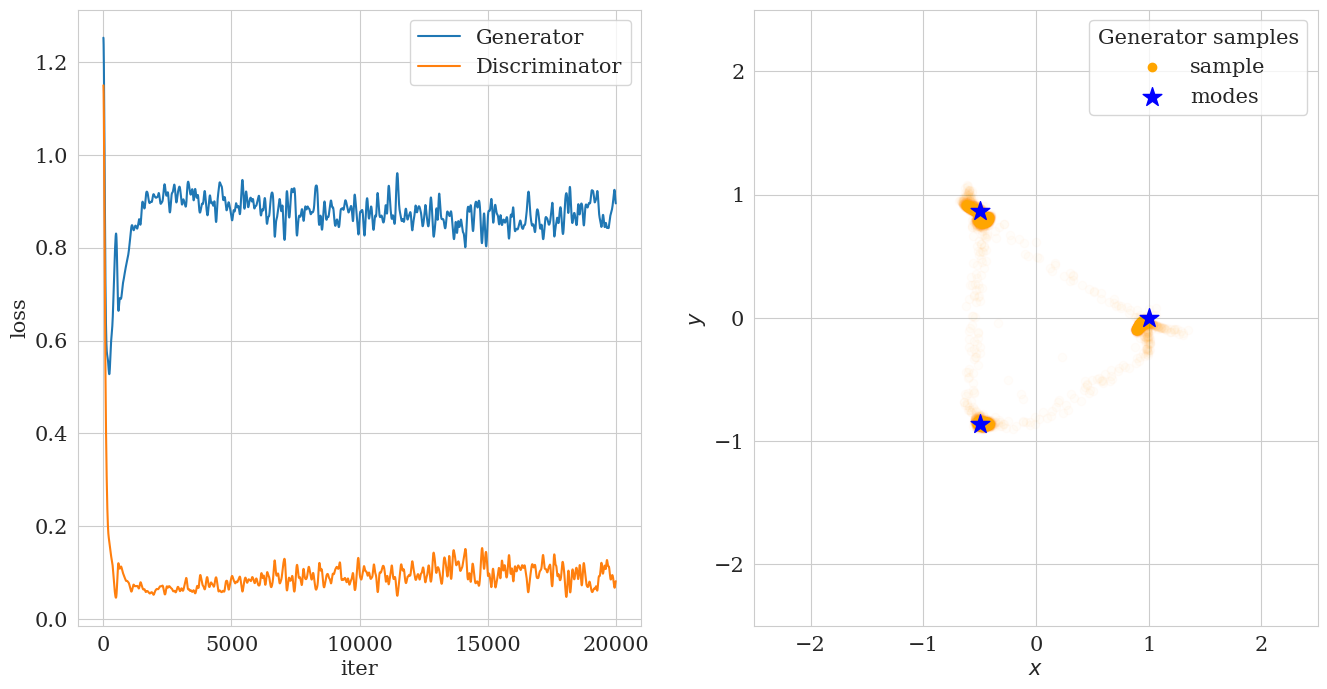

In [66]:
gan.visualize()

### More difficult data

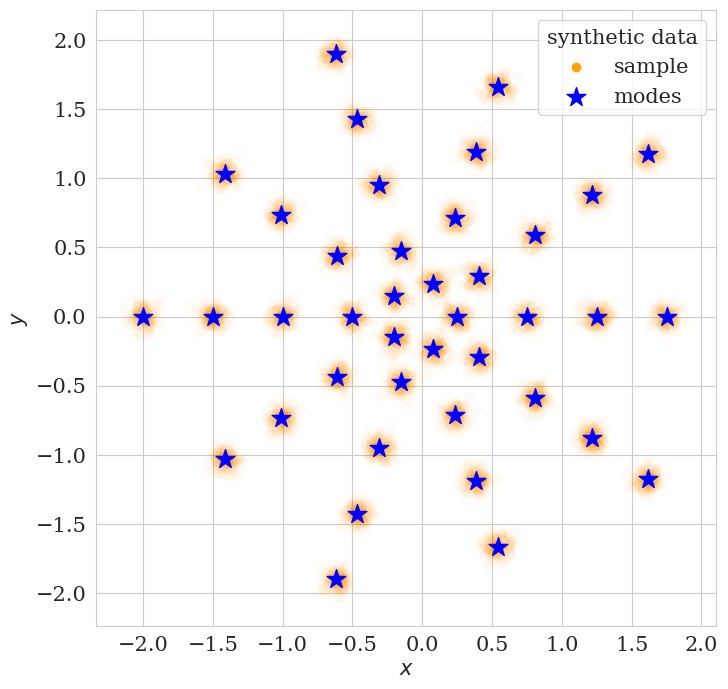

In [56]:
dataset = SyntheticDataset(num_modes=5, scale=0.05, rings=8, num_samples=10000)

plt.figure(figsize=(8, 8))
draw_samples(plt.axes(), dataset.samples, dataset.centers)

In [57]:
gan = GAN(num_layers_gen=10, num_layers_dis=4)
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)
gan.train(dataloader, num_epochs=100)

Generator params: 2482, Discriminator params: 641


  0%|          | 0/100 [00:00<?, ?it/s]

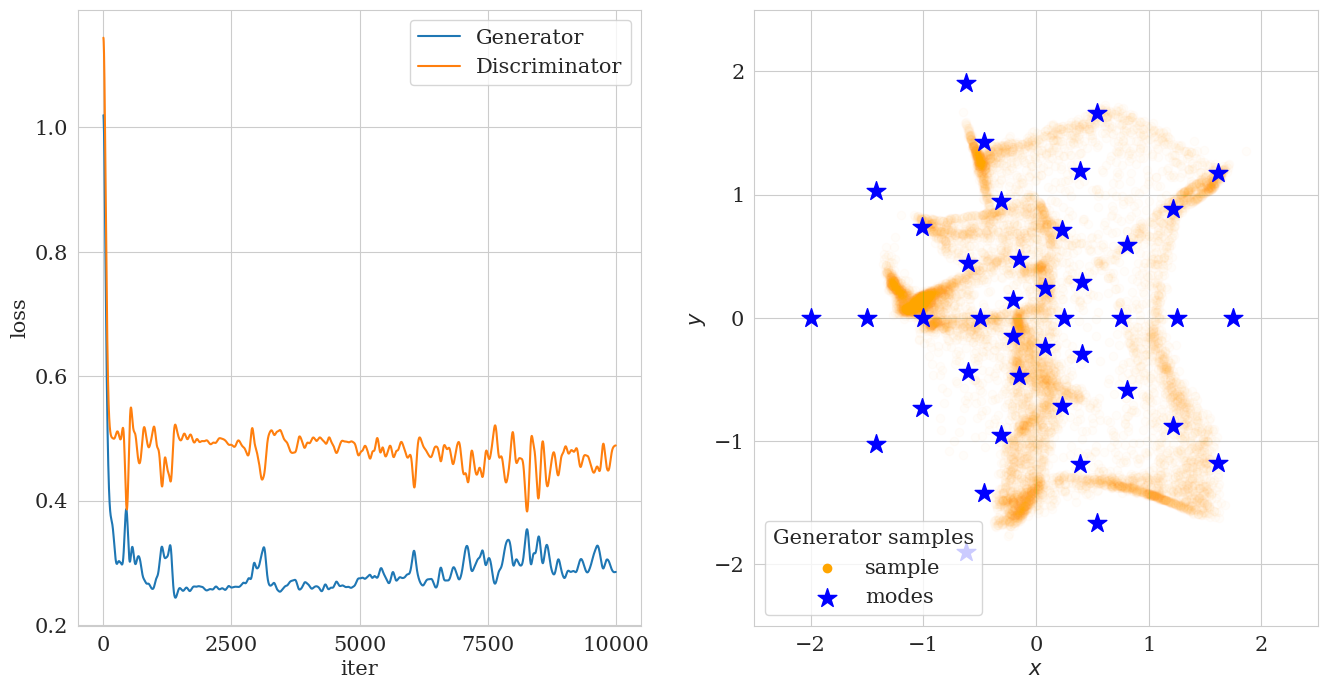

In [58]:
gan.visualize()

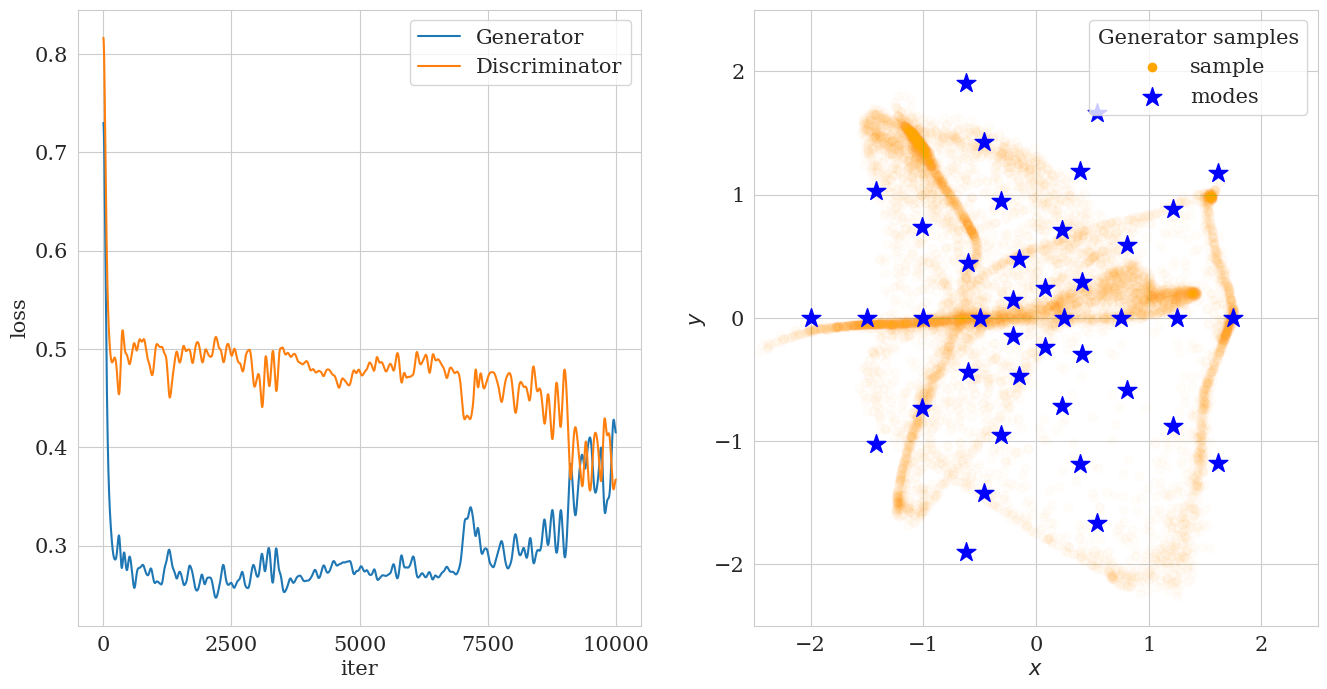

In [285]:
gan.visualize()

### Conditional GAN

In [12]:
from scipy.ndimage import gaussian_filter1d
import torch.nn.functional as F


class GAN(object):
    def __init__(self, num_layers_gen=4, num_layers_dis=4, noise_dim=8,
                 mlp_dim=16, out_dim=2, num_classes=1, alpha=1):
        self.num_layers_gen = num_layers_gen
        self.num_layers_dis = num_layers_dis
        self.noise_dim = noise_dim
        self.mlp_dim = mlp_dim
        self.out_dim = out_dim
        self.num_classes = num_classes
        self.alpha = alpha

        self.net_G = network(num_layers=num_layers_gen, input_dim=noise_dim + num_classes,
                             mlp_dim=mlp_dim, out_dim=out_dim).to(device)
        self.net_D = network(num_layers=num_layers_dis, input_dim=out_dim,
                             mlp_dim=mlp_dim, out_dim=num_classes + 1).to(device)

        self.opt_G = torch.optim.Adam(self.net_G.parameters(), lr=7e-4)
        self.opt_D = torch.optim.Adam(self.net_D.parameters(), lr=5e-4)
#         self.criterion = nn.BCEWithLogitsLoss()

        params_G = sum(param.numel() for param in self.net_G.parameters())
        params_D = sum(param.numel() for param in self.net_D.parameters())
        print(f'Generator params: {params_G}, Discriminator params: {params_D}')

        self.losses_G, self.losses_D = [], []

    def train(self, dataloader, num_epochs):
        self.net_G.train(), self.net_D.train()

        for epoch in tqdm(range(1, num_epochs + 1)):
            for x_real, cls in dataloader:
                x_real = x_real.to(device)
                cls = cls.to(device)
                fake_labels = torch.zeros(x_real.shape[0]).to(device)
                real_labels = torch.ones(x_real.shape[0]).to(device)

                self.opt_G.zero_grad()
                self.opt_D.zero_grad()

                z = torch.randn(x_real.shape[0], self.noise_dim).to(device)
                cls_ohe = torch.zeros(x_real.shape[0], self.num_classes).to(device)
                cls_ohe[cls] = 1
                x_fake = self.net_G(torch.cat([z, cls_ohe], dim=1))

                raw_fake = self.net_D(x_fake.detach())
                raw_real = self.net_D(x_real)

                logits_fake = raw_fake[..., 0]
                logits_real = raw_real[..., 0]
#                 loss_D = self.criterion(logits_fake, fake_labels) + \
#                          self.criterion(logits_real, real_labels)
                gan_loss_D = ((logits_fake - fake_labels) ** 2).mean() + ((logits_real - real_labels) ** 2).mean()
                cls_loss_D = F.cross_entropy(raw_real[..., 1:], cls)
                loss_D = gan_loss_D + self.alpha * cls_loss_D
                loss_D.backward()
                self.opt_D.step()

                # here we can freeze net_D
                raw_fake = self.net_D(x_fake)
                logits_fake = raw_fake[..., 0]
#                 loss_G = self.criterion(logits_fake, real_labels)
                gan_loss_G = ((logits_fake - real_labels) ** 2).mean()
                cls_loss_G = F.cross_entropy(raw_fake[..., 1:], cls)
                loss_G = gan_loss_G + self.alpha * cls_loss_G
                loss_G.backward()
                self.opt_G.step()

                self.losses_G.append(loss_G.item())
                self.losses_D.append(loss_D.item())

    @torch.inference_mode()
    def sample(self, num_samples, cls):
        self.net_G.eval()
        z = torch.randn(num_samples, self.noise_dim).to(device)
        cls_ohe = torch.zeros(num_samples, self.num_classes).to(device)
        cls_ohe[cls] = 1
        samples = self.net_G(torch.cat([z, cls_ohe], dim=1))
        return samples.cpu()

    def visualize(self, cls):
        fig, axs = plt.subplots(1, 2, figsize=(16, 8))
        samples = self.sample(num_samples=10000, cls=cls)

        plot_losses(axs[0], gaussian_filter1d(self.losses_G, sigma=30),
                    gaussian_filter1d(self.losses_D, sigma=30))

        draw_samples(axs[1], samples, dataset.centers, title='Generator samples')
        axs[0].set_xticks(np.linspace(0, len(self.losses_G), 5))
        axs[1].set_xlim((-2.5, 2.5))
        axs[1].set_ylim((-2.5, 2.5))
        plt.show()

In [13]:
class SyntheticDataset(Dataset):
    def __init__(self, num_modes=8, scale=0.1, rings=1, num_samples=10000):
        # assert rings in [1, 2]
        self.num_modes = num_modes
        self.scale = scale
        self.num_samples = num_samples
        
        angles = torch.linspace(0, 2 * torch.pi, num_modes + 1)[:-1]
        self.centers = torch.stack([angles.cos(), angles.sin()], dim=1)

        for i in range(1, rings):
            out_angles = angles + (i % 2) * torch.pi / num_modes
            out_centers = torch.stack([(i + 1) * out_angles.cos(), (i + 1) * out_angles.sin()], dim=1)
            self.centers = torch.cat([
                self.centers, out_centers
            ], dim=0)

        if rings > 1:
            self.centers *= 2 / rings
        self.samples, self.cls, self.assignments = self.sample(num_samples)

    def sample(self, num_samples):
        samples = self.scale * torch.randn(num_samples, 2)
        assignments = torch.randint(high=self.centers.shape[0], size=(num_samples, ))
        cls = (assignments // self.num_modes)
        samples = samples + self.centers[assignments]
        return samples, cls, assignments

    def __len__(self):
        return self.num_samples

    def __getitem__(self, item):
        return self.samples[item], self.cls[item]

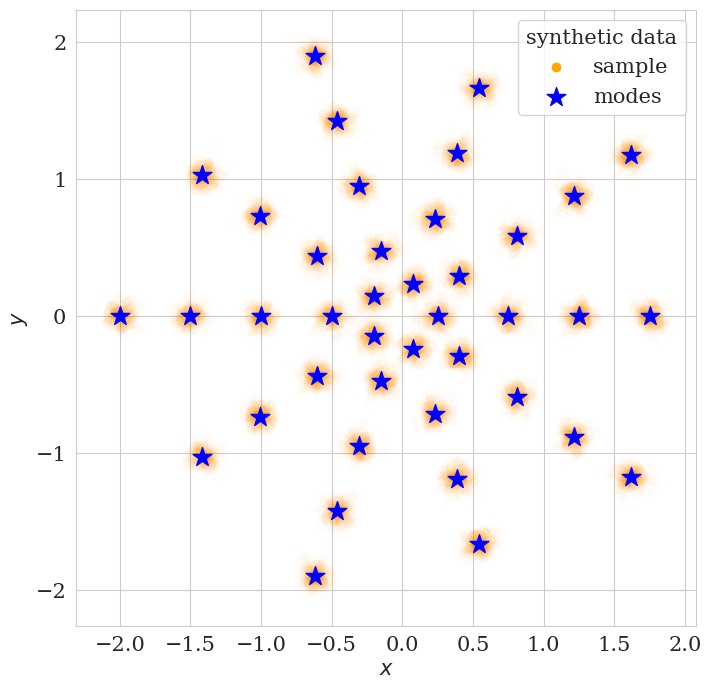

In [15]:
dataset = SyntheticDataset(num_modes=5, scale=0.05, rings=8, num_samples=10000)

plt.figure(figsize=(8, 8))
draw_samples(plt.axes(), dataset.samples, dataset.centers)

In [32]:
gan = GAN(num_layers_gen=32, num_layers_dis=4, num_classes=8, alpha=0.1)
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)
gan.train(dataloader, num_epochs=100)

Generator params: 8946, Discriminator params: 777


  0%|          | 0/100 [00:00<?, ?it/s]

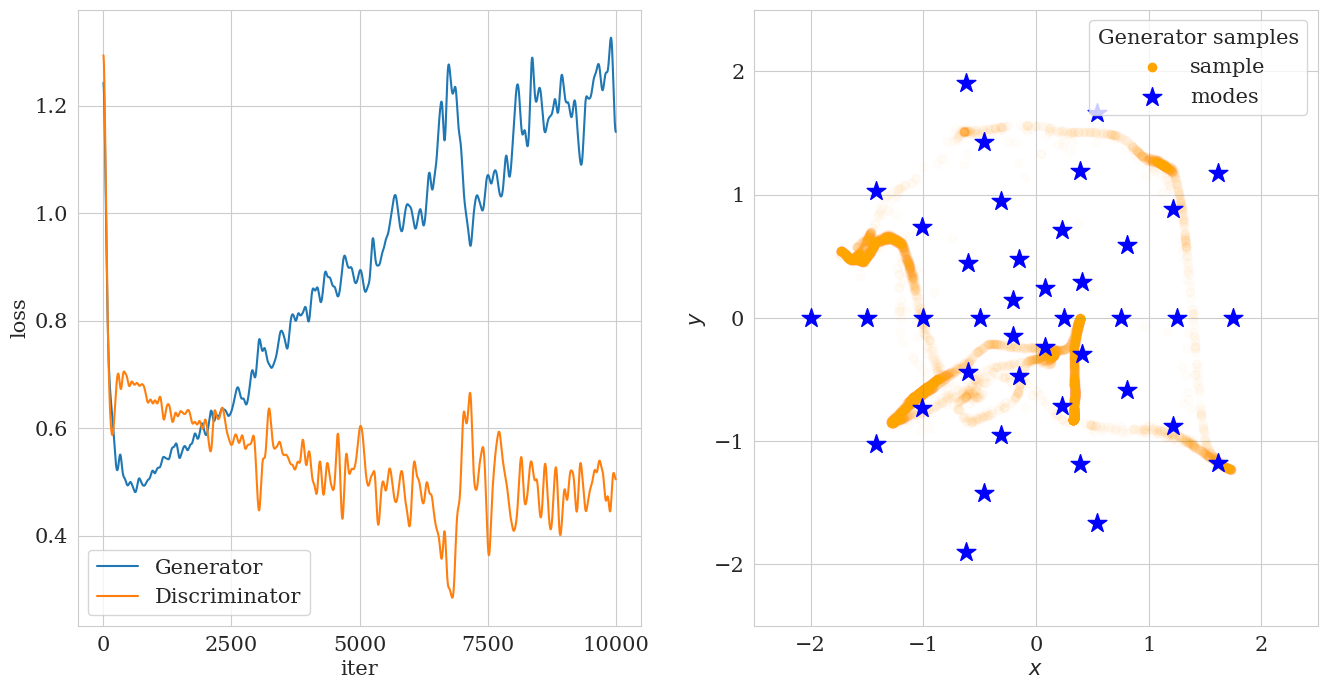

In [33]:
gan.visualize(cls=0)